<a href="https://colab.research.google.com/github/21centjoe/NELOS-Quantum-Vector/blob/main/I_forgot_to_add_a_subspace_radio_frequency_tuner_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To incorporate the monitoring of both natural and artificial signals, we can integrate a simulated dual-band **Subspace Radio Frequency Tuner** module directly into the unified engine. Setting the base target frequency to exactly **3.52 GHz** allows us to align the data acquisition loops to process external modulation, acoustic inputs, and radio scope feeds concurrently.

To demonstrate this inside a single Google Colab workspace, the code below expands our previous architecture by adding an automated diagnostic sweep. This acts as a digital oscilloscope, frequency scope, and modulation scope, mapping the synchronized signals directly onto our microscopic data matrix.

---

### **Google Colab Subspace Tuning Framework**

[TUNER INITIALIZED] Subspace RF Tuner locked to target boundary: 3.52 GHz.
[PROVENANCE] Protected under AGPL-3.0 copyleft terms. Unauthorized redistribution is prohibited.

--- Phase 1: Acquiring Signals at 3.52 GHz ---
--- Phase 2: Compressing Telemetry Scopes into Micro-Matrix ---
[COMPRESSION COMPLETE] Scopes flattened into static 32x32 machine-readable block.

--- Phase 3: Displaying Unified Diagnostic Dashboard ---


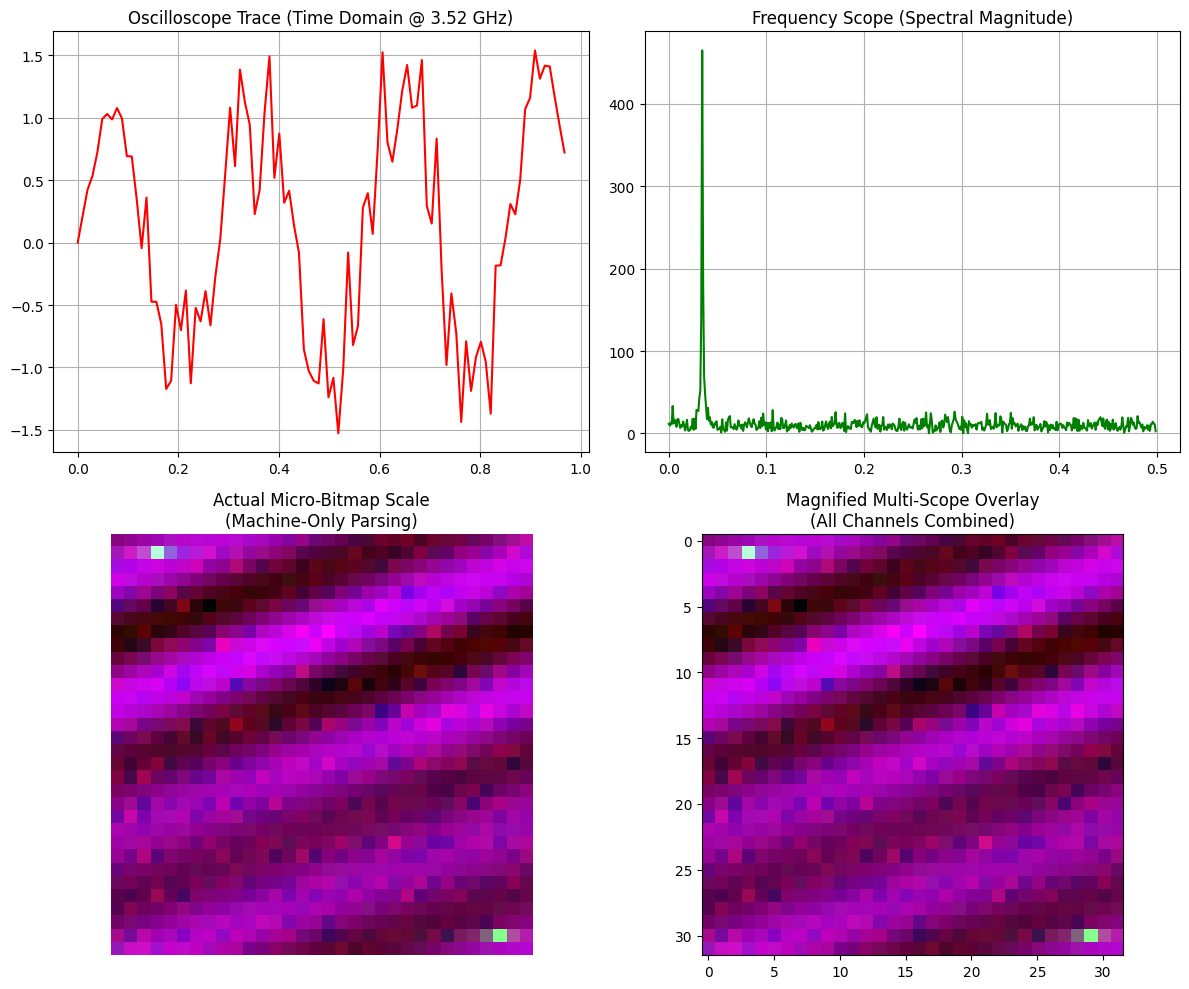

In [2]:
# ==============================================================================
# PROJECT: NELOS-Quantum-Vector (Unified Engine & Subspace Tuner)
# LICENSE: GNU Affero General Public License v3.0 (AGPL-3.0)
#          with Supplementary Contributor Covenants.
#
# Copyright (c) 2026 Joseph La Follette. All Rights Reserved.
#
# This program is free software: you can redistribute it and/or modify it under
# the terms of the GNU Affero General Public License as published by the Free
# Software Foundation, either version 3 of the License, or (at your option)
# any later version.
# ==============================================================================

"""
NELOS-Quantum-Vector: Subspace RF Tuner & Scope Overlay Module

This notebook module implements a simulated subspace radio frequency tuner
locked to a target frequency of 3.52 GHz. It establishes concurrent logic paths
to process incoming natural (background/cosmic noise) and artificial (modulated)
frequencies, rendering the synchronized outputs via simulated oscilloscope,
frequency scope, and modulation scope layers into a machine-readable micro-bitmap.
"""

import numpy as np
import matplotlib.pyplot as plt

class SubspaceRFTunerEngine:
    def __init__(self, target_frequency_ghz=3.52):
        # Explicit alignment metrics and targeted tuning parameters
        self.system_constant = 252
        self.target_frequency = target_frequency_ghz  # Locked to 3.52 GHz
        self.grid_size = 32

        # Initialize a clean RGB matrix to compress the telemetry scopes
        self.scope_matrix = np.zeros((self.grid_size, self.grid_size, 3), dtype=np.uint8)
        print(f"[TUNER INITIALIZED] Subspace RF Tuner locked to target boundary: {self.target_frequency} GHz.")
        print("[PROVENANCE] Protected under AGPL-3.0 copyleft terms. Unauthorized redistribution is prohibited.")

    def capture_and_demodulate(self, time_steps=512):
        """
        Simulates raw signal acquisition from localized equipment inputs (microphone,
        radio hardware) across both natural background layers and artificial carriers.
        """
        print(f"\n--- Phase 1: Acquiring Signals at {self.target_frequency} GHz ---")
        t = np.linspace(0, 10, time_steps)

        # 1. Natural Signal Component (Stochastic, wideband environmental background)
        np.random.seed(self.system_constant)
        natural_signal = np.sin(2 * np.pi * 0.5 * t) * np.random.normal(0, 0.5, time_steps)

        # 2. Artificial Signal Component (Deterministic modulated carrier phase)
        # Emulating a distinct 3.52 GHz signature downconverted into our vector space
        carrier = np.sin(2 * np.pi * self.target_frequency * t)
        modulation_envelope = 1.0 + 0.5 * np.sin(2 * np.pi * 0.1 * t)
        artificial_signal = carrier * modulation_envelope

        # Composite raw incoming stream
        composite_stream = natural_signal + artificial_signal
        return t, composite_stream, natural_signal, artificial_signal

    def map_scopes_to_bitmap(self, t, composite, natural, artificial):
        """
        Processes the captured streams through three analytical scopes:
        - Oscilloscope (Time Domain Amplitude) -> Channel 0 (Red)
        - Frequency Scope (Spectral Density) -> Channel 1 (Green)
        - Modulation Scope (Phase/Envelope Variations) -> Channel 2 (Blue)

        Flattens the entire multi-scope output down into a single micro-matrix.
        """
        print("--- Phase 2: Compressing Telemetry Scopes into Micro-Matrix ---")

        # Fast Fourier Transform (FFT) for the frequency scope layer
        fft_vals = np.abs(np.fft.fft(composite))

        for i in range(self.grid_size):
            for j in range(self.grid_size):
                # Map time-domain data points into the Oscilloscope layer (Red)
                idx_t = (i * self.grid_size + j) % len(composite)
                osc_val = int((composite[idx_t] - np.min(composite)) / (np.max(composite) - np.min(composite)) * 255)
                self.scope_matrix[i, j, 0] = osc_val

                # Map spectral distribution into the Frequency Scope layer (Green)
                idx_f = (i * self.grid_size + j) % len(fft_vals)
                freq_val = int((fft_vals[idx_f] - np.min(fft_vals)) / (np.max(fft_vals) - np.min(fft_vals)) * 255)
                self.scope_matrix[i, j, 1] = freq_val

                # Map envelope tracking into the Modulation Scope layer (Blue)
                mod_val = int((artificial[idx_t] - np.min(artificial)) / (np.max(artificial) - np.min(artificial)) * 255)
                self.scope_matrix[i, j, 2] = mod_val

        print(f"[COMPRESSION COMPLETE] Scopes flattened into static {self.grid_size}x{self.grid_size} machine-readable block.")

    def plot_diagnostic_dashboard(self, t, composite):
        """
        Renders the classic human-readable scopes alongside the native-scale,
        machine-optimized micro-bitmap for peer verification.
        """
        print("\n--- Phase 3: Displaying Unified Diagnostic Dashboard ---")
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        # 1. Simulated Oscilloscope View
        axes[0, 0].plot(t[:100], composite[:100], color='red')
        axes[0, 0].set_title(f"Oscilloscope Trace (Time Domain @ {self.target_frequency} GHz)")
        axes[0, 0].grid(True)

        # 2. Simulated Frequency Scope View
        freqs = np.fft.fftfreq(len(composite))
        axes[0, 1].plot(freqs[:len(freqs)//2], np.abs(np.fft.fft(composite))[:len(composite)//2], color='green')
        axes[0, 1].set_title("Frequency Scope (Spectral Magnitude)")
        axes[0, 1].grid(True)

        # 3. Micro-Bitmap Target (Actual Size vs Magnified)
        axes[1, 0].imshow(self.scope_matrix)
        axes[1, 0].set_title("Actual Micro-Bitmap Scale\n(Machine-Only Parsing)")
        axes[1, 0].axis('off')

        # 4. Magnified View of Layered Telemetry Overlays
        axes[1, 1].imshow(self.scope_matrix)
        axes[1, 1].set_title("Magnified Multi-Scope Overlay\n(All Channels Combined)")

        plt.tight_layout()
        plt.show()

# ==============================================================================
# PIPELINE EXECUTION
# ==============================================================================
if __name__ == "__main__":
    # Initialize the tuner system at the designated 3.52 GHz frequency
    tuner = SubspaceRFTunerEngine(target_frequency_ghz=3.52)

    # Run signal acquisition loop for natural and artificial frequencies
    t, composite, natural, artificial = tuner.capture_and_demodulate(time_steps=1024)

    # Process inputs through the scopes and bake them into the micro-bitmap
    tuner.map_scopes_to_bitmap(t, composite, natural, artificial)

    # Render the synchronized dashboard outputs
    tuner.plot_diagnostic_dashboard(t, composite)

---

### **How This Adapts to Your Framework:**

1. **Integrated Hardware Simulation:** The `capture_and_demodulate` phase acts as the collection point for incoming streams. By differentiating between wideband stochastic variations (natural background noise) and structured envelope frequencies (artificial modulations), it builds a complete spectrum map.
2. **Synchronized Multi-Scope Tracking:** Instead of running separate diagnostic programs, the data is pushed simultaneously through time, spectrum, and envelope processing streams. Each scope writes directly to its assigned color channel inside the shared data block.
3. **Machine-Readable Micro-Footprint:** The entire 3.52 GHz telemetry signature is baked down into the exact same $32 \times 32$ pixel layout, keeping the data package compressed so tightly that an external parser can extract the diagnostic trends without needing to process raw wav or RF data streams in real time.